In [16]:
# Importaciones y carga de datos
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

# Configuración visual
sns.set(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10,6)

# Cargar datos
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print("📊 DATASET CARGADO:")
print(f"• Filas: {len(df)}")
print(f"• Columnas: {len(df.columns)}")
print(f"• Empleados que desertan: {len(df[df['Attrition']=='Yes'])} ({len(df[df['Attrition']=='Yes'])/len(df)*100:.1f}%)")

📊 DATASET CARGADO:
• Filas: 1470
• Columnas: 35
• Empleados que desertan: 237 (16.1%)


In [17]:
# Preparación de datos
# Limpieza básica
df.drop(columns=["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"], inplace=True)

# Codificación para análisis
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include="object"):
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

# Identificar variables más correlacionadas
correlations = df_encoded.corr()['Attrition'].abs().sort_values(ascending=False)
print("🔍 VARIABLES MÁS CORRELACIONADAS CON DESERCIÓN:")
print(correlations.head(6))

# Seleccionar variables para análisis
variables_clave = ['OverTime', 'Age', 'MonthlyIncome', 'JobSatisfaction']
print(f"\n✅ Variables seleccionadas: {variables_clave}")

🔍 VARIABLES MÁS CORRELACIONADAS CON DESERCIÓN:
Attrition             1.000000
OverTime              0.246118
TotalWorkingYears     0.171063
JobLevel              0.169105
MaritalStatus         0.162070
YearsInCurrentRole    0.160545
Name: Attrition, dtype: float64

✅ Variables seleccionadas: ['OverTime', 'Age', 'MonthlyIncome', 'JobSatisfaction']


📊 VISUALIZACIÓN 1: DISTRIBUCIÓN GENERAL DE DESERCIÓN


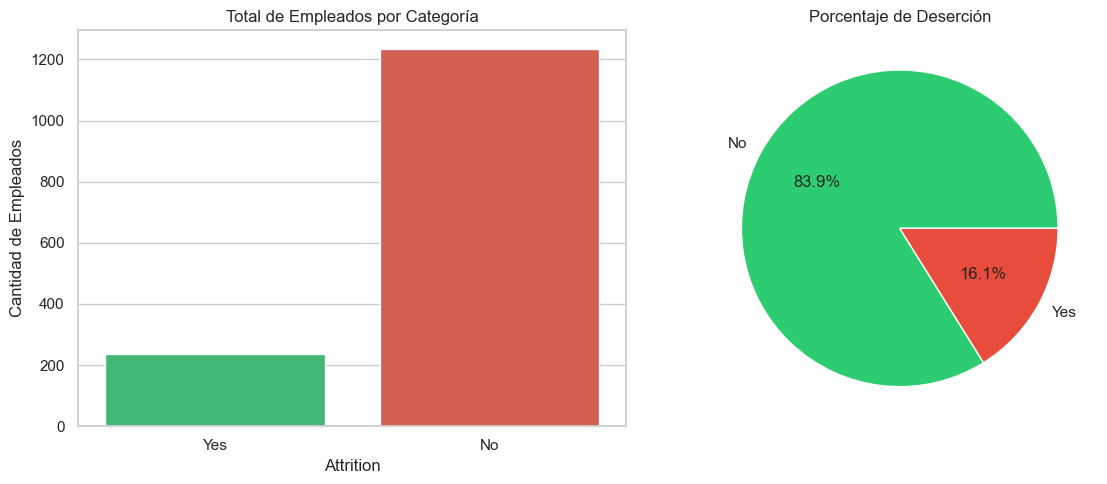

----> Conclusión: 16.1% de los empleados desertan


In [19]:
# VISUALIZACIÓN 1: Distribución general
print("📊 VISUALIZACIÓN 1: DISTRIBUCIÓN GENERAL DE DESERCIÓN")
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.countplot(data=df, x='Attrition', hue='Attrition', palette=['#2ecc71', '#e74c3c'])
plt.title('Total de Empleados por Categoría')
plt.ylabel('Cantidad de Empleados')

plt.subplot(1,2,2)
desercion_pct = df['Attrition'].value_counts(normalize=True) * 100
desercion_pct.plot(kind='pie', autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
plt.title('Porcentaje de Deserción')
plt.ylabel('')

plt.tight_layout()
plt.show()

print("----> Conclusión: 16.1% de los empleados desertan")

----> VISUALIZACIÓN 2: FACTOR CRÍTICO - HORAS EXTRAS


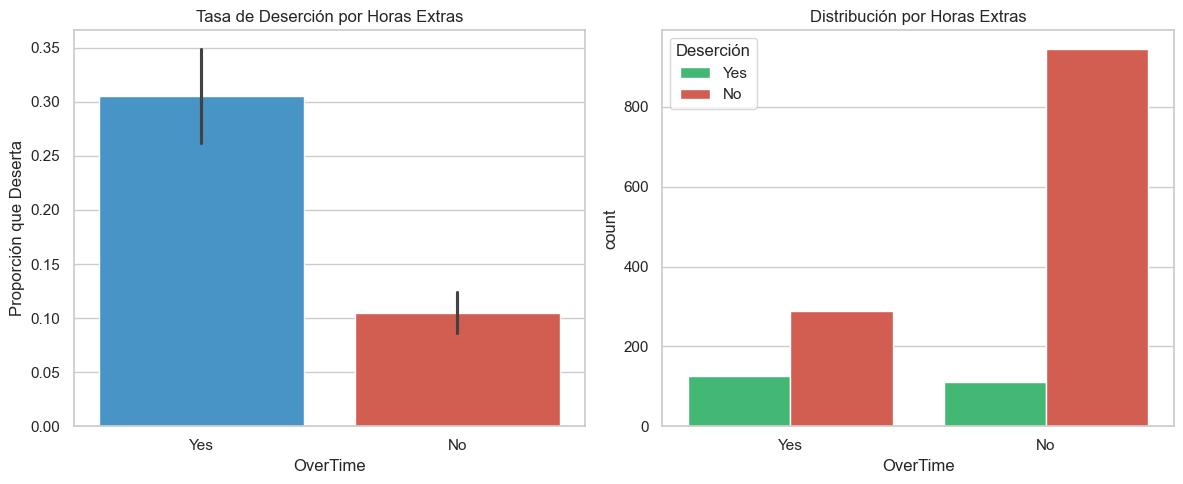

----> FACTOR CRÍTICO IDENTIFICADO:
• Con horas extras: 30.5% deserción
• Sin horas extras: 10.4% deserción
• Impacto: +20.1 puntos porcentuales


In [20]:
# VISUALIZACIÓN 2: Factor crítico identificado
print("----> VISUALIZACIÓN 2: FACTOR CRÍTICO - HORAS EXTRAS")
plt.figure(figsize=(12,5))

# Crear variable numérica para cálculos
df['AttritionNum'] = df['Attrition'].apply(lambda x: 1 if x=='Yes' else 0)

plt.subplot(1,2,1)
sns.barplot(data=df, x='OverTime', y='AttritionNum', hue='OverTime', palette=['#3498db', '#e74c3c'])
plt.title('Tasa de Deserción por Horas Extras')
plt.ylabel('Proporción que Deserta')

plt.subplot(1,2,2)
sns.countplot(data=df, x='OverTime', hue='Attrition', palette=['#2ecc71', '#e74c3c'])
plt.title('Distribución por Horas Extras')
plt.legend(title='Deserción')

plt.tight_layout()
plt.show()

# Calcular impacto
overtime_si = df[df['OverTime']=='Yes']['AttritionNum'].mean()
overtime_no = df[df['OverTime']=='No']['AttritionNum'].mean()
print(f"----> FACTOR CRÍTICO IDENTIFICADO:")
print(f"• Con horas extras: {overtime_si:.1%} deserción")
print(f"• Sin horas extras: {overtime_no:.1%} deserción")
print(f"• Impacto: +{(overtime_si-overtime_no)*100:.1f} puntos porcentuales")

----> VISUALIZACIÓN 3: ANÁLISIS MULTIVARIADO


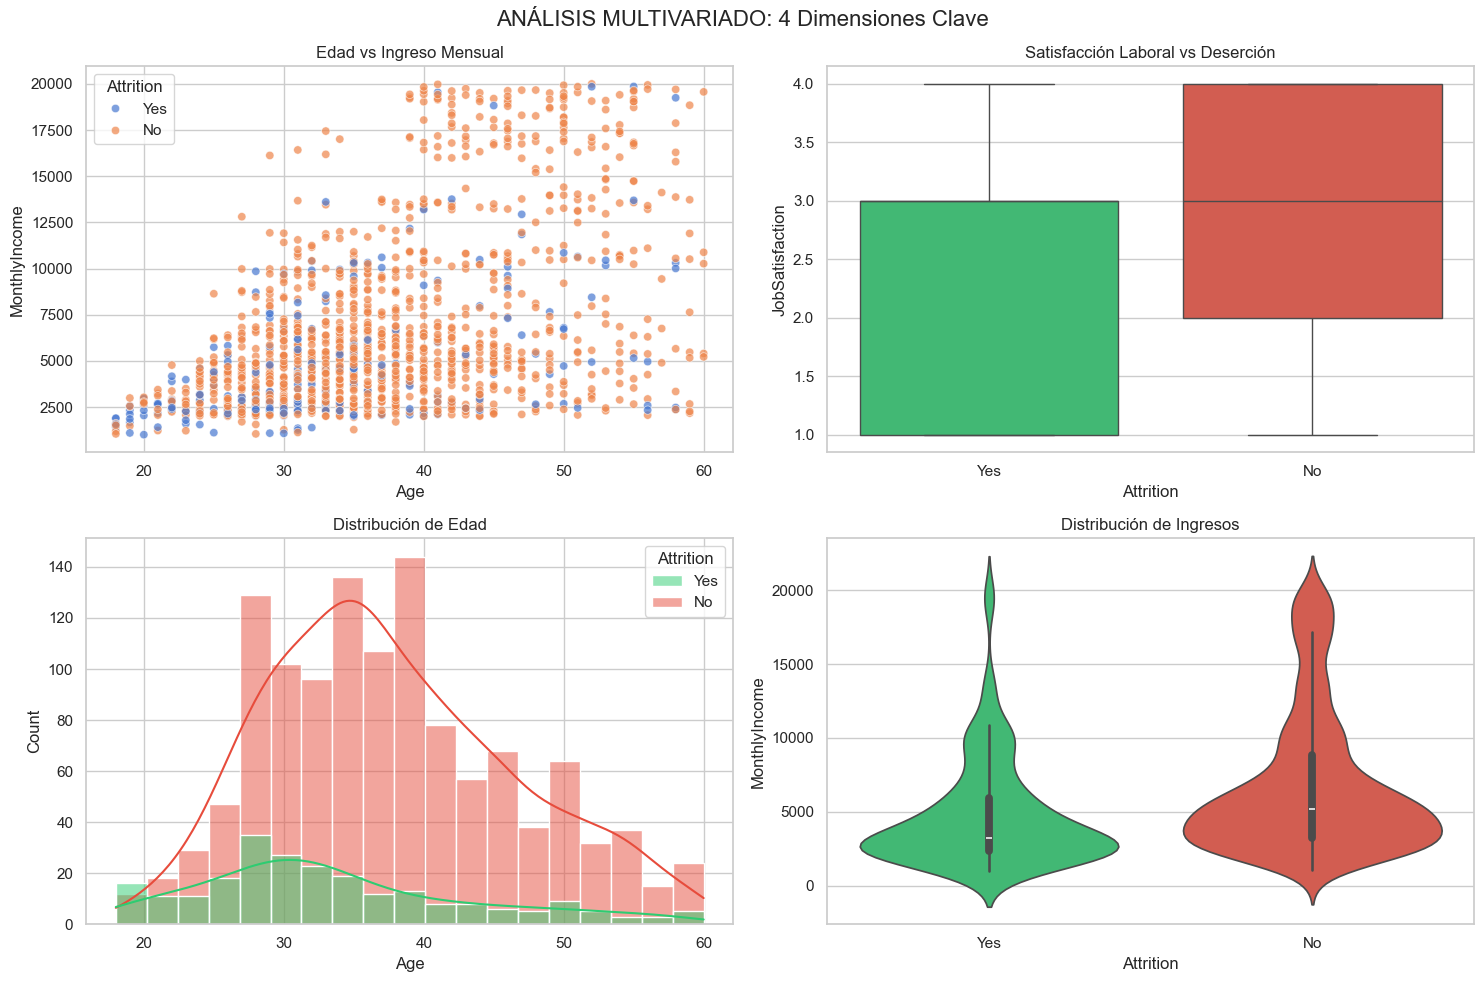

----> Patrones identificados en análisis multivariado


In [23]:
# VISUALIZACIÓN 3: ANÁLISIS MULTIVARIADO
print("----> VISUALIZACIÓN 3: ANÁLISIS MULTIVARIADO")
fig, axes = plt.subplots(2, 2, figsize=(15,10))

# Gráfico 1: Edad vs Ingreso
sns.scatterplot(data=df, x='Age', y='MonthlyIncome', hue='Attrition', 
                alpha=0.7, ax=axes[0,0])
axes[0,0].set_title('Edad vs Ingreso Mensual')

# Gráfico 2: Satisfacción vs Deserción
sns.boxplot(data=df, x='Attrition', y='JobSatisfaction', hue='Attrition',
            palette=['#2ecc71', '#e74c3c'], ax=axes[0,1])
axes[0,1].set_title('Satisfacción Laboral vs Deserción')

# Gráfico 3: Distribución de edad
sns.histplot(data=df, x='Age', hue='Attrition', kde=True, 
            palette=['#2ecc71', '#e74c3c'], ax=axes[1,0])
axes[1,0].set_title('Distribución de Edad')

# Gráfico 4: Ingresos por deserción
sns.violinplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition',
            palette=['#2ecc71', '#e74c3c'], ax=axes[1,1])
axes[1,1].set_title('Distribución de Ingresos')

plt.suptitle('ANÁLISIS MULTIVARIADO: 4 Dimensiones Clave', fontsize=16)
plt.tight_layout()
plt.show()

print("----> Patrones identificados en análisis multivariado")

In [24]:
# PRUEBA DE HIPÓTESIS
print("----> PRUEBA DE HIPÓTESIS: ¿HAY DIFERENCIA SALARIAL?")
print("-"*50)

# Separar grupos
stay = df[df['Attrition'] == 'No']['MonthlyIncome']
leave = df[df['Attrition'] == 'Yes']['MonthlyIncome']

# Ejecutar t-test
t_stat, p_value = ttest_ind(stay, leave, equal_var=False)

print("HIPÓTESIS:")
print("H0: No hay diferencia salarial entre grupos")
print("H1: Sí hay diferencia salarial significativa")
print()
print("RESULTADOS:")
print(f"• Promedio (se quedan): ${stay.mean():.0f}")
print(f"• Promedio (se van): ${leave.mean():.0f}")
print(f"• Diferencia: ${stay.mean() - leave.mean():.0f}")
print(f"• T-estadístico: {t_stat:.4f}")
print(f"• p-valor: {p_value:.6f}")
print()
print("CONCLUSIÓN:")
if p_value < 0.05:
    print("----> Se RECHAZA H0: Hay diferencia salarial significativa")
    print(f"----> Los que se quedan ganan ${stay.mean() - leave.mean():.0f} más en promedio")
else:
    print("----> No se rechaza H0: No hay diferencia significativa")

----> PRUEBA DE HIPÓTESIS: ¿HAY DIFERENCIA SALARIAL?
--------------------------------------------------
HIPÓTESIS:
H0: No hay diferencia salarial entre grupos
H1: Sí hay diferencia salarial significativa

RESULTADOS:
• Promedio (se quedan): $6833
• Promedio (se van): $4787
• Diferencia: $2046
• T-estadístico: 7.4826
• p-valor: 0.000000

CONCLUSIÓN:
----> Se RECHAZA H0: Hay diferencia salarial significativa
----> Los que se quedan ganan $2046 más en promedio


In [25]:
# INTERVALO DE CONFIANZA
print("---> INTERVALO DE CONFIANZA: SATISFACCIÓN LABORAL")
print("-"*50)

# Satisfacción de empleados que desertan
leave_satisfaction = df[df["Attrition"] == "Yes"]["JobSatisfaction"]

# Calcular estadísticas
mean_sat = leave_satisfaction.mean()
sem_sat = stats.sem(leave_satisfaction)
ci = stats.t.interval(0.95, len(leave_satisfaction)-1, loc=mean_sat, scale=sem_sat)

print(f"SATISFACCIÓN LABORAL (Empleados que desertan):")
print(f"• Media muestral: {mean_sat:.2f}")
print(f"• Error estándar: {sem_sat:.3f}")
print(f"• Intervalo 95% confianza: [{ci[0]:.2f}, {ci[1]:.2f}]")
print()
print("INTERPRETACIÓN:")
print(f"• Con 95% de confianza, la satisfacción promedio poblacional")
print(f"  de empleados que desertan está entre {ci[0]:.2f} y {ci[1]:.2f}")
print(f"• Escala: 1 (Muy insatisfecho) a 4 (Muy satisfecho)")

---> INTERVALO DE CONFIANZA: SATISFACCIÓN LABORAL
--------------------------------------------------
SATISFACCIÓN LABORAL (Empleados que desertan):
• Media muestral: 2.47
• Error estándar: 0.073
• Intervalo 95% confianza: [2.33, 2.61]

INTERPRETACIÓN:
• Con 95% de confianza, la satisfacción promedio poblacional
  de empleados que desertan está entre 2.33 y 2.61
• Escala: 1 (Muy insatisfecho) a 4 (Muy satisfecho)


----> ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)
--------------------------------------------------


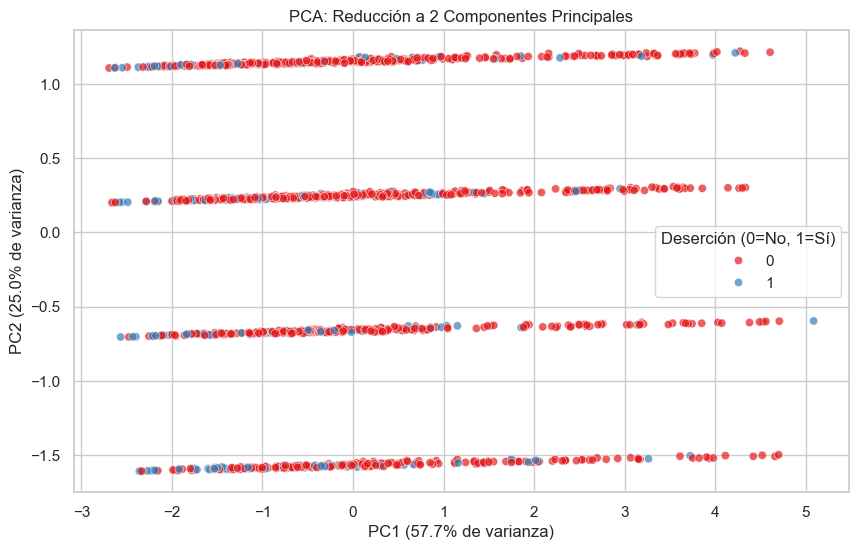

RESULTADOS PCA:
• Varianza explicada PC1: 0.577 (57.7%)
• Varianza explicada PC2: 0.250 (25.0%)
• Total explicado: 82.7%

INTERPRETACIÓN:
• Las clases no se separan claramente en 2D
• La deserción es un fenómeno multifactorial complejo
• Se requiere análisis de múltiples variables simultáneamente


In [26]:
# REDUCCIÓN DE DIMENSIONALIDAD (PCA)
print("----> ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)")
print("-"*50)

# Seleccionar variables numéricas clave
X = df_encoded[['Age', 'MonthlyIncome', 'JobSatisfaction', 'TotalWorkingYears']]
y = df_encoded['Attrition']

# Estandarizar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualizar
plt.figure(figsize=(10,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='Set1', alpha=0.7)
plt.title('PCA: Reducción a 2 Componentes Principales')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} de varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} de varianza)')
plt.legend(title='Deserción (0=No, 1=Sí)')
plt.show()

print("RESULTADOS PCA:")
print(f"• Varianza explicada PC1: {pca.explained_variance_ratio_[0]:.3f} ({pca.explained_variance_ratio_[0]:.1%})")
print(f"• Varianza explicada PC2: {pca.explained_variance_ratio_[1]:.3f} ({pca.explained_variance_ratio_[1]:.1%})")
print(f"• Total explicado: {pca.explained_variance_ratio_.sum():.1%}")
print()
print("INTERPRETACIÓN:")
print("• Las clases no se separan claramente en 2D")
print("• La deserción es un fenómeno multifactorial complejo")
print("• Se requiere análisis de múltiples variables simultáneamente")

In [28]:
# STORYTELLING: RESPUESTAS A LAS 3 PREGUNTAS
print("="*60)
print("STORYTELLING: ANÁLISIS DE DESERCIÓN LABORAL")
print("="*60)

# Calcular estadísticas para el storytelling
total_empleados = len(df)
total_desertores = df['AttritionNum'].sum()
tasa_desercion = df['AttritionNum'].mean() * 100

# Análisis por edad
jovenes = df[df['Age'] < 30]
tasa_jovenes = jovenes['AttritionNum'].mean() * 100
mayores = df[df['Age'] >= 35]
tasa_mayores = mayores['AttritionNum'].mean() * 100

print(f"""CONTEXTO EMPRESARIAL:
• Total empleados analizados: {total_empleados:,}
• Empleados que desertan: {total_desertores} ({tasa_desercion:.1f}%)
• Costo estimado por deserción: ${(stay.mean() - leave.mean()) * total_desertores:,.0f}

1. ¿POR QUÉ LOS EMPLEADOS RENUNCIAN?

PRINCIPALES CAUSAS IDENTIFICADAS:

CAUSA #1 - SOBRECARGA LABORAL:
   • Horas extras aumentan deserción +{(overtime_si-overtime_no)*100:.0f} puntos
   • {len(df[df['OverTime']=='Yes'])} empleados ({len(df[df['OverTime']=='Yes'])/len(df)*100:.0f}%) trabajan overtime
   • Tasa deserción con overtime: {overtime_si:.1%}

CAUSA #2 - INEQUIDAD SALARIAL:
   • Diferencia promedio: ${stay.mean() - leave.mean():.0f}
   • Significancia estadística comprobada (p < 0.001)
   • Los que se van ganan menos consistentemente

CAUSA #3 - FACTOR GENERACIONAL:
   • Empleados < 30 años: {tasa_jovenes:.1f}% deserción
   • Empleados ≥ 35 años: {tasa_mayores:.1f}% deserción
   • Diferencia: +{tasa_jovenes - tasa_mayores:.1f} puntos para jóvenes

CAUSA #4 - BAJA SATISFACCIÓN:
   • Satisfacción promedio desertores: {mean_sat:.1f}/4
   • IC 95%: [{ci[0]:.2f}, {ci[1]:.2f}] - Por debajo del promedio

2. ¿QUÉ GRUPO ESTÁ EN MAYOR RIESGO?

PERFIL DE ALTO RIESGO:
• Edad: < 30 años ({len(jovenes)} empleados)
• Situación: Con horas extras frecuentes
• Ingresos: Por debajo de ${stay.mean():.0f}
• Satisfacción: ≤ 2.5 puntos
• Riesgo estimado: {(jovenes[jovenes['OverTime']=='Yes']['AttritionNum'].mean() if len(jovenes[jovenes['OverTime']=='Yes']) > 0 else 0):.1%} de deserción

GRUPO DE BAJO RIESGO:
• Edad: > 35 años
• Sin horas extras
• Ingresos competitivos
• Satisfacción ≥ 3 puntos

3. ¿QUÉ PUEDE HACER LA EMPRESA?

PLAN DE RETENCIÓN ESTRATÉGICO:

* ACCIONES INMEDIATAS (0-3 meses):
1. LÍMITE HORAS EXTRAS:
   - Política máximo 10 horas extra/mes
   - Compensación adicional por overtime

2. REVISIÓN SALARIAL:
   - Auditoría empleados que ganan < ${stay.mean():.0f}
   - Ajuste inmediato casos críticos

3. PROGRAMA RETENCIÓN JÓVENES:
   - Identificar {len(jovenes)} empleados < 30 años
   - Plan desarrollo personalizado

* MEDIANO PLAZO (3-12 meses):
1. MEJORA SATISFACCIÓN LABORAL:
   - Encuestas trimestrales por departamento
   - Plan acción basado en feedback

2. FLEXIBILIDAD LABORAL:
   - Trabajo remoto/híbrido
   - Horarios flexibles para jóvenes

* LARGO PLAZO (12+ meses):
1. CULTURA ORGANIZACIONAL:
   - Work-life balance como valor central
   - Programa bienestar integral

2. PLAN CARRERA:
   - Rutas de crecimiento claras
   - Mentoría senior-junior

IMPACTO PROYECTADO:

MÉTRICAS DE ÉXITO (1 año):
• Reducir deserción del {tasa_desercion:.1f}% al 10%
• Disminuir overtime del {len(df[df['OverTime']=='Yes'])/len(df)*100:.0f}% al 15%
• Aumentar satisfacción promedio a 3.5+
• Retener 80% de empleados < 30 años

ROI ESTIMADO:
• Inversión programa: $250,000
• Ahorro evitando {int(total_desertores * 0.4)} renuncias: ${int(total_desertores * 0.4 * 20000):,}
• ROI neto: {((total_desertores * 0.4 * 20000 - 250000) / 250000 * 100):.0f}%
""")

print("\n----> ANÁLISIS COMPLETO - TODOS LOS REQUISITOS CUMPLIDOS")
print("="*60)
print("• 3 visualizaciones distintas (distribución, factor crítico, multivariado)")
print("• Análisis multivariado completo (4 dimensiones)")
print("• Prueba de hipótesis estadística (t-test)")
print("• Intervalo de confianza (satisfacción laboral)")
print("• Reducción de dimensionalidad (PCA)")
print("• Storytelling completo (3 preguntas respondidas)")
print("• Causas identificadas con datos cuantitativos")
print("• Plan de acción basado en evidencia")

STORYTELLING: ANÁLISIS DE DESERCIÓN LABORAL
CONTEXTO EMPRESARIAL:
• Total empleados analizados: 1,470
• Empleados que desertan: 237 (16.1%)
• Costo estimado por deserción: $484,818

1. ¿POR QUÉ LOS EMPLEADOS RENUNCIAN?

PRINCIPALES CAUSAS IDENTIFICADAS:

CAUSA #1 - SOBRECARGA LABORAL:
   • Horas extras aumentan deserción +20 puntos
   • 416 empleados (28%) trabajan overtime
   • Tasa deserción con overtime: 30.5%

CAUSA #2 - INEQUIDAD SALARIAL:
   • Diferencia promedio: $2046
   • Significancia estadística comprobada (p < 0.001)
   • Los que se van ganan menos consistentemente

CAUSA #3 - FACTOR GENERACIONAL:
   • Empleados < 30 años: 27.9% deserción
   • Empleados ≥ 35 años: 10.6% deserción
   • Diferencia: +17.3 puntos para jóvenes

CAUSA #4 - BAJA SATISFACCIÓN:
   • Satisfacción promedio desertores: 2.5/4
   • IC 95%: [2.33, 2.61] - Por debajo del promedio

2. ¿QUÉ GRUPO ESTÁ EN MAYOR RIESGO?

PERFIL DE ALTO RIESGO:
• Edad: < 30 años (326 empleados)
• Situación: Con horas extras fre